In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import trim_mean
from scipy.signal import coherence, csd
from matplotlib.gridspec import GridSpec
import matplotlib.animation as animation

# Insolation input is the only input data
#1. read the insolation time series based on Laskar 2004 model
input_file = "Input_insolation_time_series_La2004.csv"
df = pd.read_csv(input_file)
time_col = df.columns[0]
insol_col = df.columns[1]
time = df.iloc[:, 0].values
df.head()

,time/ka,W/m2
0,-10000,499.864207
1,-9999,506.266451
2,-9998,509.600472
3,-9997,509.084264
4,-9996,504.618827


In [15]:
#2. generate thresold series
step = 0.1    # step can be modified for low or high resolution
thresholds = np.arange(428, 511, step) 
thr_data = {}
for t in thresholds:
    col_name = f"thr_{t:.1f}"  
    thr_data[col_name] = np.full(len(df), t)
df_thr = pd.DataFrame(thr_data)
df_thr.insert(0, time_col, df[time_col].values)
df_thr.to_csv("Output_data_1_threshold.csv", index=False)
df_thr.head()

,time/ka,thr_428.0,thr_428.1,thr_428.2,thr_428.3,thr_428.4,thr_428.5,thr_428.6,thr_428.7,thr_428.8,...,thr_510.0,thr_510.1,thr_510.2,thr_510.3,thr_510.4,thr_510.5,thr_510.6,thr_510.7,thr_510.8,thr_510.9
0,-10000,428.0,428.1,428.2,428.3,428.4,428.5,428.6,428.7,428.8,...,510.0,510.1,510.2,510.3,510.4,510.5,510.6,510.7,510.8,510.9
1,-9999,428.0,428.1,428.2,428.3,428.4,428.5,428.6,428.7,428.8,...,510.0,510.1,510.2,510.3,510.4,510.5,510.6,510.7,510.8,510.9
2,-9998,428.0,428.1,428.2,428.3,428.4,428.5,428.6,428.7,428.8,...,510.0,510.1,510.2,510.3,510.4,510.5,510.6,510.7,510.8,510.9
3,-9997,428.0,428.1,428.2,428.3,428.4,428.5,428.6,428.7,428.8,...,510.0,510.1,510.2,510.3,510.4,510.5,510.6,510.7,510.8,510.9
4,-9996,428.0,428.1,428.2,428.3,428.4,428.5,428.6,428.7,428.8,...,510.0,510.1,510.2,510.3,510.4,510.5,510.6,510.7,510.8,510.9


In [16]:
#3. generate 1/-1 rank series
insol_values = df[insol_col].values
rank_data = {}
for t in thresholds:
    col_name = f"thr_{t:.1f}"  
    rank_data[col_name] = np.where(insol_values > t, 1, -1)
df_rank = pd.DataFrame(rank_data)
df_rank.insert(0, time_col, df[time_col].values)
df_rank.to_csv("Output_data_2_rank.csv", index=False)
df_rank.head()

,time/ka,thr_428.0,thr_428.1,thr_428.2,thr_428.3,thr_428.4,thr_428.5,thr_428.6,thr_428.7,thr_428.8,...,thr_510.0,thr_510.1,thr_510.2,thr_510.3,thr_510.4,thr_510.5,thr_510.6,thr_510.7,thr_510.8,thr_510.9
0,-10000,1,1,1,1,1,1,1,1,1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
1,-9999,1,1,1,1,1,1,1,1,1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
2,-9998,1,1,1,1,1,1,1,1,1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
3,-9997,1,1,1,1,1,1,1,1,1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
4,-9996,1,1,1,1,1,1,1,1,1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


In [17]:
#4. generate couplet series
def make_couplet(seq):
    temp = seq.rename('v').reset_index()
    temp['block'] = (temp['v'] != temp['v'].shift()).cumsum()
    blocks = temp.groupby('block').agg(
        start=('index', 'first'),
        end=('index', 'last'),
        val=('v', 'first'),
        len=('index', 'count')
    ).reset_index(drop=True)
    out = pd.Series(0, index=seq.index)
    i = 0
    while i < len(blocks):
        cur = blocks.iloc[i]
        if cur['val'] == 1 and i+1 < len(blocks) and blocks.iloc[i+1]['val'] == -1:
            nxt = blocks.iloc[i+1]
            out.loc[cur['start']:nxt['end']] = cur['len'] + nxt['len']
            i += 2
        else:
            out.loc[cur['start']:cur['end']] = cur['len']
            i += 1
    return out
coup_data = {}
coup_data[time_col] = df_rank[time_col].values
for col in df_rank.columns[1:]:
    coup_data[col] = make_couplet(df_rank[col].astype(int)).values
df_coup = pd.DataFrame(coup_data)
df_coup.to_csv("Output_data_3_couplet.csv", index=False)
df_coup.head()

,time/ka,thr_428.0,thr_428.1,thr_428.2,thr_428.3,thr_428.4,thr_428.5,thr_428.6,thr_428.7,thr_428.8,...,thr_510.0,thr_510.1,thr_510.2,thr_510.3,thr_510.4,thr_510.5,thr_510.6,thr_510.7,thr_510.8,thr_510.9
0,-10000,106,106,106,106,106,106,106,106,106,...,115,115,115,115,115,115,115,115,115,115
1,-9999,106,106,106,106,106,106,106,106,106,...,115,115,115,115,115,115,115,115,115,115
2,-9998,106,106,106,106,106,106,106,106,106,...,115,115,115,115,115,115,115,115,115,115
3,-9997,106,106,106,106,106,106,106,106,106,...,115,115,115,115,115,115,115,115,115,115
4,-9996,106,106,106,106,106,106,106,106,106,...,115,115,115,115,115,115,115,115,115,115


In [18]:
#5. calculate the proportion, duration, coherence and phase of rank and couplet proxies
def calc_metrics(df1, df2):
    rows = []
    for col in df1.columns[1:]:
        x = df1[col]
        y = df2[col]
        cnt1 = (x == 1).sum()
        cnt_neg1 = (x == -1).sum()
        prop = cnt1 / (cnt1 + cnt_neg1)
        dur = trim_mean(y, 0.2)
        f, coh = coherence(x, y, fs=1, nperseg=4096, noverlap=2500)
        _, pxy = csd(x, y, fs=1, nperseg=4096, noverlap=2500)
        phase = np.abs(np.angle(pxy, deg=True))
        m = (f >= 0.0015) & (f <= 0.0035)
        coh_mean = np.mean(coh[m])
        phase_mean = np.mean(phase[m])
        rows.append({
            'Threshold': col,
            'Proportion': round(prop,4),
            'Duration': round(dur,2),
            'Coherence': round(coh_mean,3),
            'Phase': round(phase_mean,2)
        })
    return pd.DataFrame(rows)
res = calc_metrics(df_rank, df_coup)
res['Threshold'] = res['Threshold'].str.replace('thr_', '').astype(float)
res.to_csv("Output_data_4_Phase_of_rank_couplet.csv", index=False)
res.head()

,Threshold,Proportion,Duration,Coherence,Phase
0,428.0,0.9942,935.40,0.214,61.77
1,428.1,0.9941,935.59,0.233,66.77
2,428.2,0.9940,852.27,0.168,83.96
3,428.3,0.9940,852.27,0.168,83.96
4,428.4,0.9940,852.27,0.168,83.96


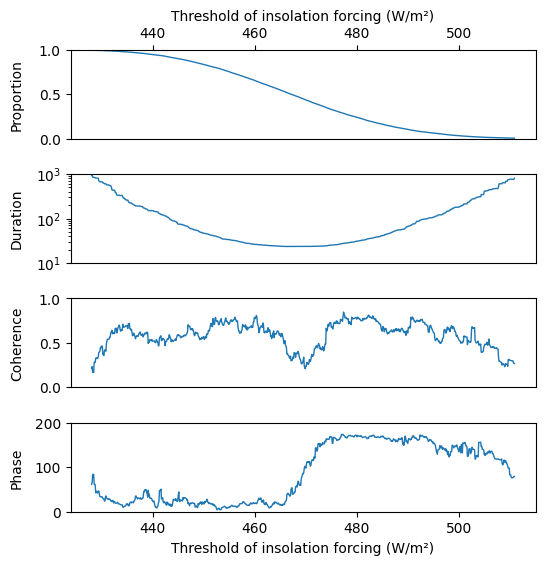

In [19]:
#6. plot the proportion, duration, coherence and phase of rank and couplet proxies
xcol = res.columns[0]
ymetrics = res.columns[1:]
ylims = [(0,1), (10,1000), (0,1), (0,200)]
fig, axes = plt.subplots(4,1, figsize=(6,6))
plt.subplots_adjust(hspace=0.4)
for i, (ax, ycol, ylim) in enumerate(zip(axes, ymetrics, ylims)):
    ax.plot(res[xcol], res[ycol], lw=1)
    ax.set_ylim(ylim)
    if i == 1:
        ax.set_yscale('log')
    ax.set_ylabel(ycol)
    ax.yaxis.set_label_coords(-0.1, 0.5)
    if i == 0:
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')
        ax.set_xlabel('Threshold of insolation forcing (W/m²)')  
    elif i == 3:  
        ax.set_xlabel('Threshold of insolation forcing (W/m²)')
        ax.tick_params(bottom=True, top=False, labelbottom=True, labeltop=False)
    else:
        ax.tick_params(bottom=False, labelbottom=False, labeltop=False)
plt.savefig("Output_figure_Phase_of_rank_couplet.png", dpi=300)
plt.show()

In [20]:
#7. make animation from insolation into rank and couplet proxies and their coherence and phase
n_frames = df_thr.shape[1] - 1
frequencies = None
all_coherence = []
all_phase = []
for frame in range(n_frames):
    r_data = df_rank.iloc[:, frame+1].values
    c_data = df_coup.iloc[:, frame+1].values
    f, coh = coherence(r_data, c_data, fs=1, nperseg=4096, noverlap=2500)
    _, pxy = csd(r_data, c_data, fs=1, nperseg=4096, noverlap=2500)
    phase = np.abs(np.angle(pxy, deg=True))
    if frequencies is None:
        frequencies = f
    all_coherence.append(coh)
    all_phase.append(phase)

colors = plt.cm.winter(np.linspace(0, 1, n_frames))
step = step  
fig = plt.figure(figsize=(12, 10))
gs = GridSpec(4, 2, height_ratios=[1, 1, 1, 1], hspace=0.3, wspace=0.3)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, :])
ax3 = fig.add_subplot(gs[2, :])
ax4 = fig.add_subplot(gs[3, 0])
ax5 = fig.add_subplot(gs[3, 1])

def init():
    ax1.plot(time, df.iloc[:, 1].values, 'gray', lw=0.5)
    ax1.set(xlim=(-10000, 0), ylim=(410, 530), ylabel='Insolation (W/m²)')
    ax1.set_xlabel('Time (kyr)')
    ax2.set(xlim=(-10000, 0), ylim=(-2, 2), ylabel='Rank')
    ax3.set(xlim=(-10000, 0), ylim=(10, 2000), ylabel='Couplet Length', yscale='log')
    ax4.set(xlim=(0, 0.005), ylim=(0, 1), ylabel='Coherence')
    ax4.set_xlabel('Frequency (cycles/kyr)')
    ax5.set(xlim=(0, 0.005), ylim=(0, 200), ylabel='Phase')
    ax5.set_xlabel('Frequency (cycles/kyr)')
    line1 = ax1.plot([], [], 'r--', lw=2, zorder=10)[0]
    line2 = ax2.plot([], [], 'b-', lw=0.8)[0]
    line3 = ax3.plot([], [], 'g-', lw=0.8)[0]
    line4 = ax4.plot([], [], 'm-', lw=1)[0]
    line5 = ax5.plot([], [], 'c-', lw=1)[0]
    return line1, line2, line3, line4, line5

lines = init()

def animate(frame):
    t_data = df_thr.iloc[:, frame+1].values
    r_data = df_rank.iloc[:, frame+1].values
    c_data = df_coup.iloc[:, frame+1].values
    lines[0].set_data(time, t_data)
    lines[1].set_data(time, r_data)
    lines[2].set_data(time, c_data)
    m = frequencies <= 0.005
    lines[3].set_data(frequencies[m], all_coherence[frame][m])
    lines[4].set_data(frequencies[m], all_phase[frame][m])
    for line in lines:
        line.set_color(colors[frame])
    thr_col_name = df_thr.columns[frame+1]
    thr_value = float(thr_col_name.replace('thr_', ''))
    ax1.set_title(f'Threshold: {thr_value:.1f} W/m²', fontweight='bold')
    return lines

print(f"Creating animation with {n_frames} frames...")
ani = animation.FuncAnimation(fig, animate, init_func=init, frames=n_frames, 
                            interval=30, blit=True, repeat=True)

print("Saving animation as GIF (this may take few minutes)...")
ani.save("Output_animation_rank_couplet.gif", writer='pillow', dpi=150, fps=20)
plt.close(fig)
print("Animation saved successfully!")

Creating animation with 830 frames...
Saving animation as GIF (this may take few minutes)...
Animation saved successfully!
